## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в барнку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

## Короткий підсумок

Я порівняла Logistic Regression, Decision Tree, KNN і бустинги. Найкращою стала LightGBM після Hyperopt. На test вона отримала ROC AUC 0.8170 і PR AUC 0.4939.

## Підготовка даних та EDA

In [1]:
import time

import numpy as np
import pandas as pd
import shap
from hyperopt import STATUS_OK, Trials, fmin, hp, space_eval, tpe
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

from bank_term_deposit_prediction.config import (
    FEATURES_TO_DROP,
    RANDOM_STATE,
    TARGET_COLUMN,
    TARGET_MAPPING,
)
from bank_term_deposit_prediction.data.preprocessing import (
    get_numerical_and_categorical_columns,
    prepare_dataset_splits,
)
from bank_term_deposit_prediction.data.summary import (
    get_category_target_summary,
    get_iqr_outlier_summary,
)
from bank_term_deposit_prediction.features import add_candidate_features
from bank_term_deposit_prediction.models import (
    build_decision_tree_pipeline,
    build_lightgbm_pipeline,
    build_logistic_pipeline,
    build_polynomial_logistic_pipeline,
    build_preprocessor,
    build_smotenc_logistic_pipeline,
    build_smotetomek_logistic_pipeline,
    build_xgboost_pipeline,
    evaluate_model,
    get_permutation_feature_importance,
)
from bank_term_deposit_prediction.paths import RAW_DATA_DIR
from bank_term_deposit_prediction.visualization import (
    plot_categorical_target_rate,
    plot_feature_importance,
    plot_numeric_target_rate,
)
from bank_term_deposit_prediction.visualization.correlation import (
    plot_correlation_heatmap,
)

In [2]:
raw_df = pd.read_csv(RAW_DATA_DIR / "bank-additional-full.csv", sep=";").copy()

In [3]:
clean_df = raw_df.drop_duplicates().reset_index(drop=True)

In [4]:
clean_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
clean_df.shape

(41176, 21)

In [6]:
splits = prepare_dataset_splits(
    clean_df,
    target=TARGET_COLUMN,
    target_mapping=TARGET_MAPPING,
    drop_columns=FEATURES_TO_DROP,
    random_state=RANDOM_STATE,
)

X_train, y_train = splits.train
X_val, y_val = splits.validation
X_test, y_test = splits.test

In [7]:
X_train.shape, X_val.shape, X_test.shape

((24705, 20), (8235, 20), (8236, 20))

In [8]:
X_train.isna().sum()

age                    0
job                    0
marital                0
education              0
default                0
housing                0
loan                   0
contact                0
month                  0
day_of_week            0
campaign               0
pdays              23803
previous               0
poutcome               0
emp.var.rate           0
cons.price.idx         0
cons.conf.idx          0
euribor3m              0
nr.employed            0
pdays_available        0
dtype: int64

In [9]:
X_train["pdays"].value_counts(dropna=False)

pdays
NaN     23803
3.0       258
6.0       233
4.0        69
9.0        39
2.0        37
7.0        37
10.0       34
12.0       31
5.0        28
13.0       26
11.0       19
15.0       18
1.0        14
14.0       12
8.0        11
0.0        10
17.0        8
16.0        7
18.0        4
22.0        2
19.0        1
25.0        1
26.0        1
27.0        1
21.0        1
Name: count, dtype: int64

In [10]:
X_train.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 24705 entries, 14794 to 2932
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              24705 non-null  int64  
 1   job              24705 non-null  str    
 2   marital          24705 non-null  str    
 3   education        24705 non-null  str    
 4   default          24705 non-null  str    
 5   housing          24705 non-null  str    
 6   loan             24705 non-null  str    
 7   contact          24705 non-null  str    
 8   month            24705 non-null  str    
 9   day_of_week      24705 non-null  str    
 10  campaign         24705 non-null  int64  
 11  pdays            902 non-null    float64
 12  previous         24705 non-null  int64  
 13  poutcome         24705 non-null  str    
 14  emp.var.rate     24705 non-null  float64
 15  cons.price.idx   24705 non-null  float64
 16  cons.conf.idx    24705 non-null  float64
 17  euribor3m        24705 no

In [11]:
X_train.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pdays_available
count,24705.000000,24705.000000,902.000000,24705.000000,24705.000000,24705.000000,24705.000000,24705.000000,24705.000000,24705.000000
mean,40.023072,2.559887,6.156319,0.170087,0.083975,93.574905,-40.485703,3.623332,5167.164578,0.036511
std,10.464257,2.768950,3.987349,0.493616,1.572716,0.578966,4.629454,1.734836,72.204851,0.187561
min,17.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.000000,1.000000,3.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.000000,2.000000,6.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.000000,3.000000,7.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.000000,56.000000,27.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [12]:
num_cols, cat_cols = get_numerical_and_categorical_columns(X_train)
num_cols, cat_cols

(['age',
  'campaign',
  'pdays',
  'previous',
  'emp.var.rate',
  'cons.price.idx',
  'cons.conf.idx',
  'euribor3m',
  'nr.employed',
  'pdays_available'],
 ['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'poutcome'])

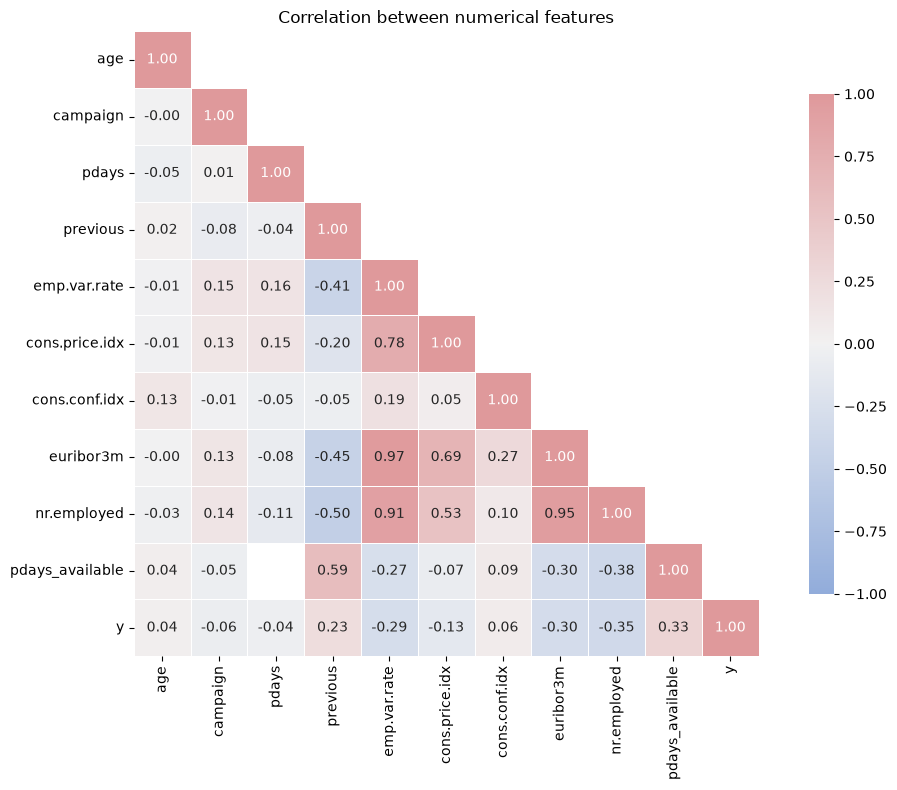

In [13]:
plot_correlation_heatmap(
    X_train,
    y_train,
    num_cols,
    TARGET_COLUMN,
)

### Висновок із кореляцій

Найбільше з `y` пов'язані попередні контакти та економічні показники. Водночас `emp.var.rate`, `euribor3m` і `nr.employed` сильно корелюють між собою, тому окремі коефіцієнти логістичної регресії слід тлумачити обережно.

In [14]:
train_eda_df = X_train.copy()
train_eda_df[TARGET_COLUMN] = y_train.reindex(X_train.index)

In [15]:
EDA_CATEGORICAL_FEATURES = [
    "job",
    "contact",
    "month",
    "poutcome",
]

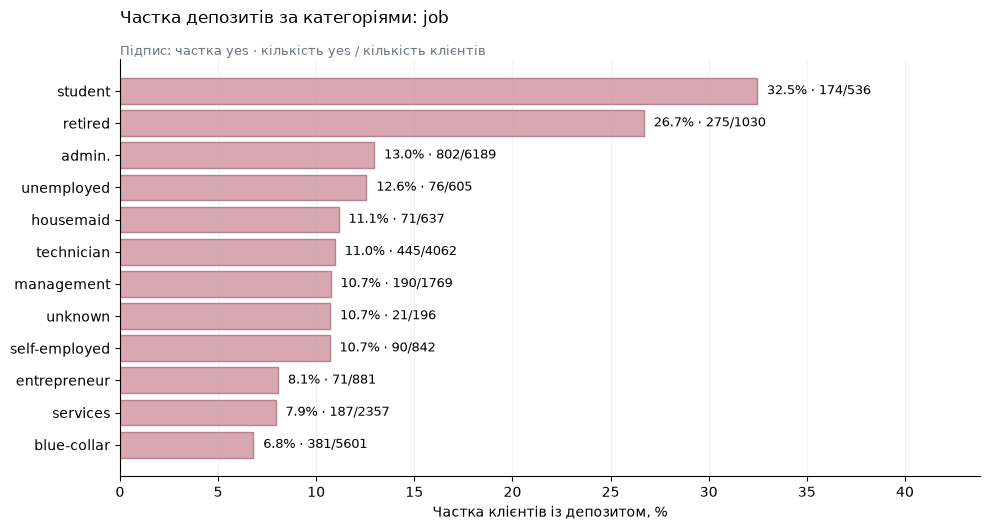

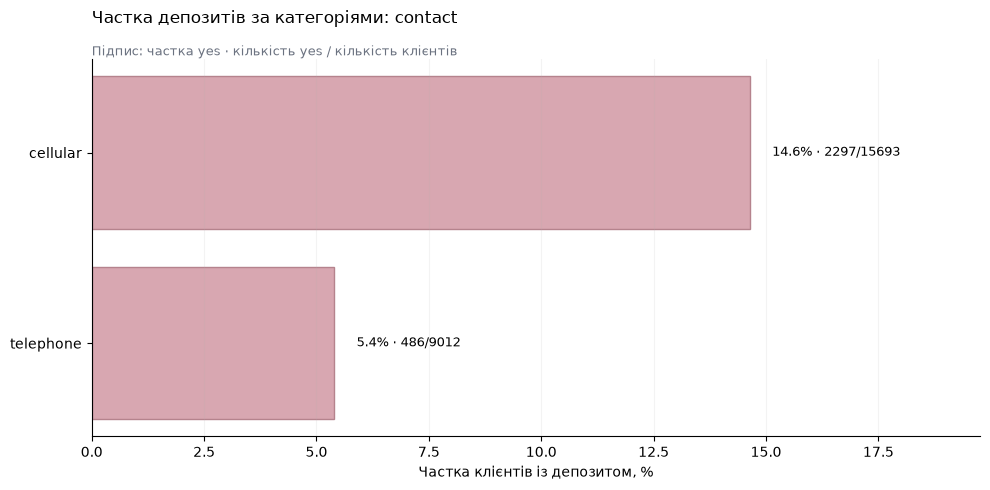

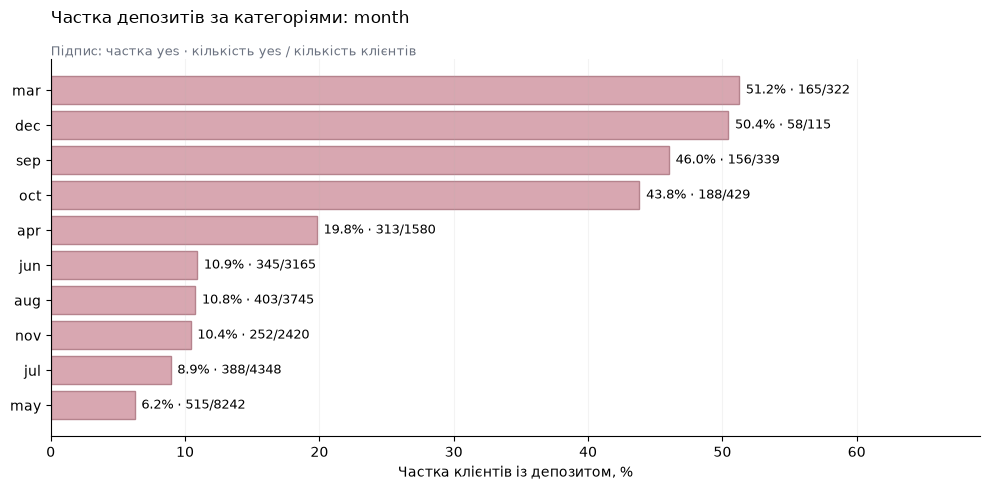

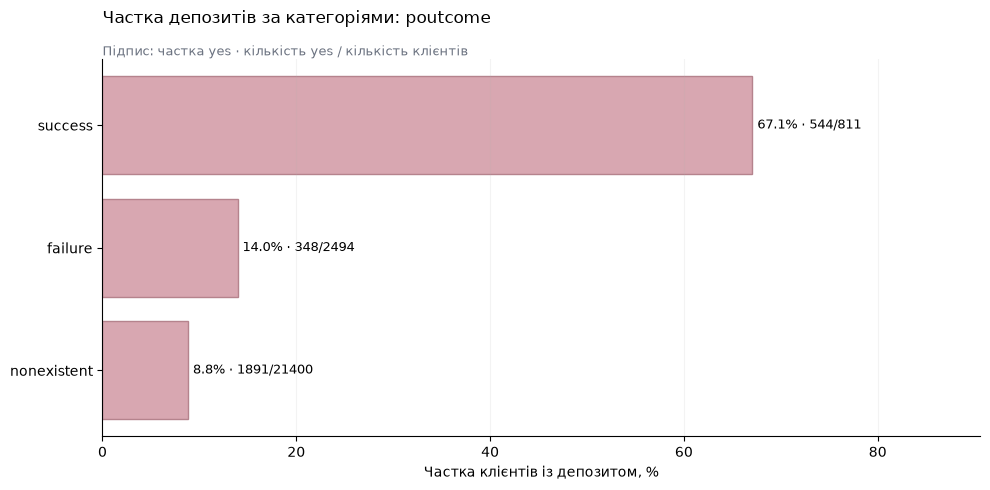

In [16]:
for column in EDA_CATEGORICAL_FEATURES:
    plot_categorical_target_rate(train_eda_df, column)

In [17]:
category_target_summary = get_category_target_summary(
    train_eda_df, cat_cols, target=TARGET_COLUMN
)
category_target_summary[["yes_rate", "share"]] *= 100
category_target_summary = category_target_summary.sort_values(
    ["column", "yes_rate"], ascending=[True, False]
)
category_target_summary.round(2)

,column,category,count,yes_rate,share
33,contact,cellular,15693,14.64,63.52
34,contact,telephone,9012,5.39,36.48
47,day_of_week,thu,5167,11.92,20.91
49,day_of_week,wed,4868,11.52,19.70
48,day_of_week,tue,4826,11.48,19.53
45,day_of_week,fri,4718,10.92,19.10
46,day_of_week,mon,5126,10.48,20.75
24,default,no,19570,12.78,79.21
25,default,unknown,5133,5.47,20.78
26,default,yes,2,0.00,0.01


### Висновок щодо категорій

Найсильніший сигнал мають результат попередньої кампанії, тип контакту та місяць. Я не об'єднувала категорії: їх небагато, а рідкісні значення можуть бути корисними. Значення `unknown` залишила окремою категорією, бо відсутність інформації також може бути сигналом.

In [18]:
NUMERIC_FEATURES_TO_PLOT = [
    "age",
    "campaign",
    "euribor3m",
    "nr.employed",
]

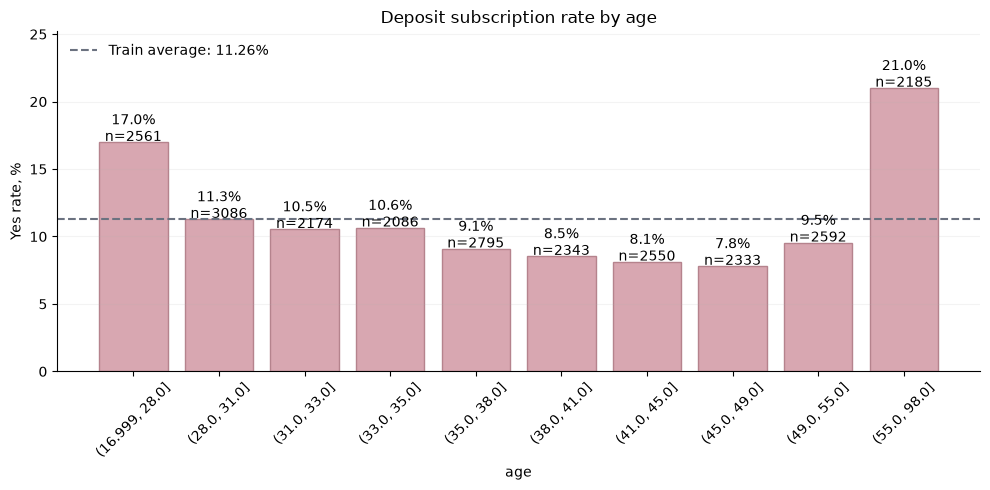

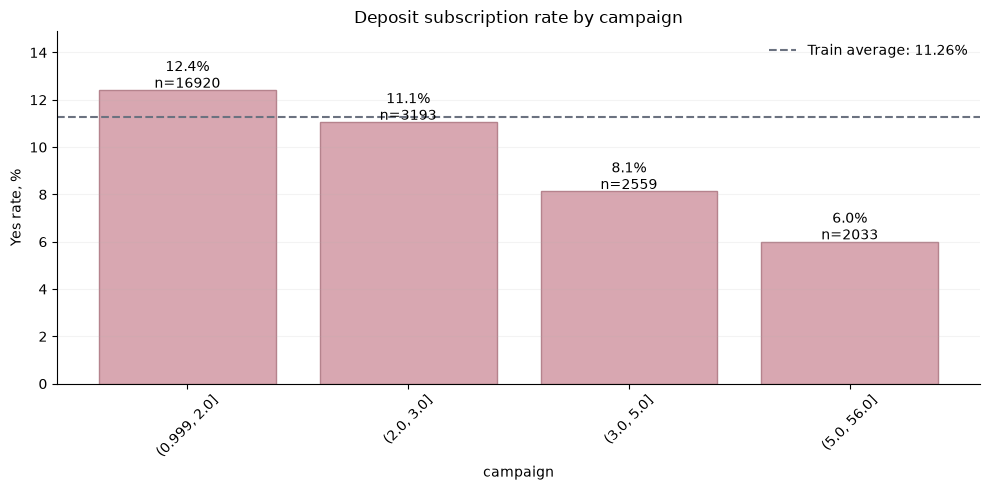

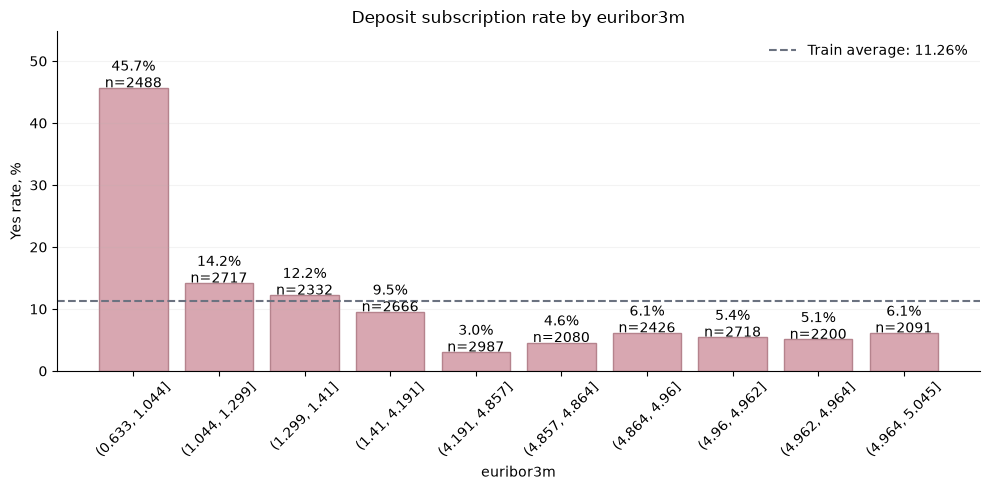

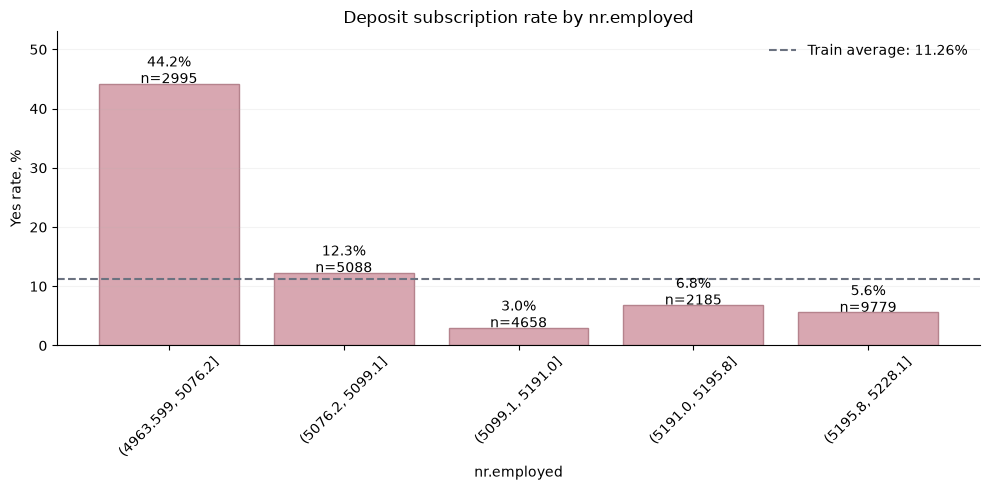

In [19]:
for column in NUMERIC_FEATURES_TO_PLOT:
    plot_numeric_target_rate(train_eda_df, column, bins=10)

In [20]:
outlier_summary = get_iqr_outlier_summary(train_eda_df, num_cols, target=TARGET_COLUMN)
outlier_summary[["outlier_share", "yes_rate_outliers"]] *= 100
outlier_summary.round(2)

,column,lower_bound,upper_bound,outlier_count,outlier_share,yes_rate_outliers,skew,p99,max
3,previous,0.00,0.00,3305,13.38,26.99,3.91,2.00,7.00
1,campaign,-2.00,6.00,1422,5.76,4.64,5.01,14.00,56.00
9,pdays_available,0.00,0.00,902,3.65,65.08,4.94,1.00,1.00
0,age,9.50,69.50,291,1.18,46.05,0.80,71.00,98.00
6,cons.conf.idx,-52.15,-26.95,275,1.11,42.55,0.31,-26.90,-26.90
2,pdays,-3.00,13.00,56,0.23,60.71,1.45,18.00,27.00
4,emp.var.rate,-6.60,6.20,0,0.00,0.00,-0.73,1.40,1.40
5,cons.price.idx,91.70,95.37,0,0.00,0.00,-0.24,94.46,94.77
7,euribor3m,-4.08,10.39,0,0.00,0.00,-0.71,4.97,5.04
8,nr.employed,4905.60,5421.60,0,0.00,0.00,-1.04,5228.10,5228.10


### Висновок щодо аутлаєрів

Правило IQR позначило значення у `previous`, `campaign`, `age`, `cons.conf.idx` і `pdays`. Для дискретних `previous` та `pdays_available` цей метод неінформативний через нульовий IQR, а решта значень виглядає реалістично. Я не видаляла ці рядки, щоб не втратити корисні спостереження.

In [21]:
unknown_stats = pd.DataFrame(
    {
        "count": X_train[cat_cols].eq("unknown").sum(),
        "percent": X_train[cat_cols].eq("unknown").mean().mul(100).round(2),
    }
)

unknown_stats = unknown_stats[unknown_stats["count"] > 0].sort_values(
    "percent", ascending=False
)

unknown_stats

,count,percent
default,5133,20.78
education,1058,4.28
housing,578,2.34
loan,578,2.34
job,196,0.79
marital,49,0.20


## Методи та метрики

Я розділила дані на train, validation і test у пропорції 60/20/20 зі збереженням частки класів. Ознаку `duration` прибрала, бо до дзвінка вона невідома і створює витік даних. Усі перетворення навчаються тільки всередині pipeline.

Основна метрика — **ROC AUC**, бо модель має добре ранжувати клієнтів за ймовірністю оформлення депозиту. Через дисбаланс класів додатково контролюю **PR AUC**, precision, recall і F1. Test використовую один раз після остаточного вибору моделі.

## 1. Logistic Regression

Почала зі зваженої логістичної регресії як простого й зрозумілого baseline.

In [22]:
preprocessor = build_preprocessor(num_cols, cat_cols)
logistic_pipeline = build_logistic_pipeline(
    preprocessor,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
logistic_pipeline.fit(X_train, y_train);

In [23]:
logistic_evaluation = evaluate_model(
    logistic_pipeline,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="Логістична регресія зі зважуванням класів",
)

Логістична регресія зі зважуванням класів — Validation classification report:
              precision    recall  f1-score   support

           0     0.9481    0.8607    0.9023      7307
           1     0.3645    0.6293    0.4617       928

    accuracy                         0.8346      8235
   macro avg     0.6563    0.7450    0.6820      8235
weighted avg     0.8824    0.8346    0.8526      8235



In [24]:
logistic_evaluation

,ROC AUC,PR AUC,Recall,Precision,F1,Accuracy
Логістична регресія зі зважуванням класів,,,,,,
Train,0.7915,0.451,0.6177,0.3620,0.4565,0.8343
Validation,0.8024,0.448,0.6293,0.3645,0.4617,0.8346


In [25]:
y_train.value_counts(normalize=True).mul(100).round(4)

y
0    88.7351
1    11.2649
Name: proportion, dtype: float64

### Додаткові ознаки

Перевірила `campaign_log`, наявність попереднього контакту, вікові групи та поліноми другого степеня.

In [26]:
X_train_engineered = add_candidate_features(X_train)
X_val_engineered = add_candidate_features(X_val)
engineered_num_cols, engineered_cat_cols = get_numerical_and_categorical_columns(
    X_train_engineered
)
engineered_model = build_logistic_pipeline(
    build_preprocessor(engineered_num_cols, engineered_cat_cols),
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
engineered_model.fit(X_train_engineered, y_train);

In [27]:
engineered_evaluation = evaluate_model(
    engineered_model,
    X_train_engineered,
    y_train,
    X_val_engineered,
    y_val,
    model_name="Логістична регресія з додатковими ознаками",
)

Логістична регресія з додатковими ознаками — Validation classification report:
              precision    recall  f1-score   support

           0     0.9480    0.8612    0.9025      7307
           1     0.3651    0.6282    0.4618       928

    accuracy                         0.8350      8235
   macro avg     0.6565    0.7447    0.6822      8235
weighted avg     0.8823    0.8350    0.8529      8235



In [28]:
polynomial_model = build_polynomial_logistic_pipeline(
    num_cols,
    cat_cols,
    degree=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
polynomial_model.fit(X_train, y_train)
polynomial_evaluation = evaluate_model(
    polynomial_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="Логістична регресія з поліномами другого степеня",
)

Логістична регресія з поліномами другого степеня — Validation classification report:
              precision    recall  f1-score   support

           0     0.9481    0.8629    0.9035      7307
           1     0.3678    0.6282    0.4640       928

    accuracy                         0.8364      8235
   macro avg     0.6580    0.7456    0.6837      8235
weighted avg     0.8827    0.8364    0.8540      8235



In [29]:
feature_comparison = pd.DataFrame(
    {
        "Baseline": logistic_evaluation.loc["Validation"],
        "Додаткові ознаки": engineered_evaluation.loc["Validation"],
        "Поліноми 2-го степеня": polynomial_evaluation.loc["Validation"],
    }
).T.sort_values("ROC AUC", ascending=False)
feature_comparison

,ROC AUC,PR AUC,Recall,Precision,F1,Accuracy
Додаткові ознаки,0.8042,0.4503,0.6282,0.3651,0.4618,0.8350
Поліноми 2-го степеня,0.8038,0.4532,0.6282,0.3678,0.4640,0.8364
Baseline,0.8024,0.4480,0.6293,0.3645,0.4617,0.8346


Додаткові ознаки змінили ROC AUC лише приблизно на 0.002. Цього недостатньо, щоб вважати їх надійним покращенням, тому у фінальну модель я їх не додавала.

### Logistic Regression + SMOTENC

Перевірила, чи допоможе збільшення кількості прикладів класу `yes`.

In [30]:
smotenc_model = build_smotenc_logistic_pipeline(
    num_cols,
    cat_cols,
    random_state=RANDOM_STATE,
)

In [31]:
smotenc_model.fit(X_train, y_train);

In [32]:
smotenc_evaluation = evaluate_model(
    smotenc_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="Логістична регресія з SMOTENC",
)

Логістична регресія з SMOTENC — Validation classification report:
              precision    recall  f1-score   support

           0     0.9397    0.8066    0.8681      7307
           1     0.2802    0.5927    0.3805       928

    accuracy                         0.7825      8235
   macro avg     0.6100    0.6996    0.6243      8235
weighted avg     0.8654    0.7825    0.8132      8235



In [33]:
smotenc_evaluation

,ROC AUC,PR AUC,Recall,Precision,F1,Accuracy
Логістична регресія з SMOTENC,,,,,,
Train,0.7491,0.4007,0.5850,0.2783,0.3772,0.7824
Validation,0.7590,0.4136,0.5927,0.2802,0.3805,0.7825


In [34]:
smotenc_model.named_steps["sampler"].sampling_strategy_

OrderedDict([(np.int8(1), np.int64(19139))])

### Logistic Regression + SMOTE-Tomek

Перевірила поєднання oversampling та очищення межі між класами.

In [35]:
smotetomek_model = build_smotetomek_logistic_pipeline(
    preprocessor,
    random_state=RANDOM_STATE,
)

In [36]:
smotetomek_model.fit(
    X_train,
    y_train,
);

In [37]:
smotetomek_evaluation = evaluate_model(
    smotetomek_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="Логістична регресія з SMOTE-Tomek",
)

Логістична регресія з SMOTE-Tomek — Validation classification report:
              precision    recall  f1-score   support

           0     0.9474    0.8582    0.9006      7307
           1     0.3589    0.6250    0.4560       928

    accuracy                         0.8319      8235
   macro avg     0.6532    0.7416    0.6783      8235
weighted avg     0.8811    0.8319    0.8505      8235



### Підбір регуляризації Logistic Regression

Перевірила L2, ElasticNet і L1-регуляризацію та підібрала `C` і `l1_ratio` через cross-validation.

In [38]:
elasticnet_model = build_logistic_pipeline(
    preprocessor,
    solver="saga",
    l1_ratio=0.5,
    C=0.1,
    class_weight="balanced",
    max_iter=5_000,
    random_state=RANDOM_STATE,
)
elasticnet_model.fit(X_train, y_train);

In [39]:
elasticnet_evaluation = evaluate_model(
    elasticnet_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="Логістична регресія з ElasticNet",
)

Логістична регресія з ElasticNet — Validation classification report:
              precision    recall  f1-score   support

           0     0.9479    0.8608    0.9022      7307
           1     0.3640    0.6272    0.4606       928

    accuracy                         0.8345      8235
   macro avg     0.6559    0.7440    0.6814      8235
weighted avg     0.8821    0.8345    0.8525      8235



In [40]:
elasticnet_parameters = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0],
    "classifier__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
}

In [41]:
stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

In [42]:
elasticnet_search = GridSearchCV(
    estimator=elasticnet_model,
    param_grid=elasticnet_parameters,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision",
    },
    refit="roc_auc",
    cv=stratified_cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=0,
)

elasticnet_search.fit(X_train, y_train);

In [43]:
print("Найкращі параметри:", elasticnet_search.best_params_)
print("Середній CV ROC AUC:", elasticnet_search.best_score_)

Найкращі параметри: {'classifier__C': 0.1, 'classifier__l1_ratio': 1.0}
Середній CV ROC AUC: 0.7853355472389898


In [44]:
best_elasticnet_model = elasticnet_search.best_estimator_

best_elasticnet_evaluation = evaluate_model(
    best_elasticnet_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="Найкраща логістична регресія (L1)",
)

best_elasticnet_evaluation

Найкраща логістична регресія (L1) — Validation classification report:
              precision    recall  f1-score   support

           0     0.9480    0.8603    0.9020      7307
           1     0.3635    0.6282    0.4605       928

    accuracy                         0.8341      8235
   macro avg     0.6557    0.7443    0.6813      8235
weighted avg     0.8821    0.8341    0.8522      8235



,ROC AUC,PR AUC,Recall,Precision,F1,Accuracy
Найкраща логістична регресія (L1),,,,,,
Train,0.7909,0.4491,0.6166,0.3585,0.4534,0.8325
Validation,0.8028,0.4483,0.6282,0.3635,0.4605,0.8341


Після підбору регуляризації я отримала ROC AUC 0.8028 проти 0.8024 у baseline. Найкращим стало `l1_ratio=1.0`, тобто чиста L1-регуляризація, але практичного покращення майже немає.

## 2. Decision Tree

Спочатку перевірила дерево без обмежень, потім підібрала параметри через GridSearchCV і RandomizedSearchCV.

In [45]:
dt_model = build_decision_tree_pipeline(num_cols, cat_cols)

dt_model.fit(X_train, y_train);

In [46]:
baseline_tree_evaluation = evaluate_model(
    dt_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="Дерево рішень без обмежень",
)

Дерево рішень без обмежень — Validation classification report:
              precision    recall  f1-score   support

           0     0.9169    0.8997    0.9082      7307
           1     0.3117    0.3578    0.3332       928

    accuracy                         0.8386      8235
   macro avg     0.6143    0.6287    0.6207      8235
weighted avg     0.8487    0.8386    0.8434      8235



In [47]:
baseline_tree_evaluation

,ROC AUC,PR AUC,Recall,Precision,F1,Accuracy
Дерево рішень без обмежень,,,,,,
Train,0.9999,0.9992,1.0000,0.9667,0.9830,0.9961
Validation,0.6291,0.1854,0.3578,0.3117,0.3332,0.8386


In [48]:
baseline_tree = dt_model.named_steps["classifier"]

baseline_tree.get_depth(), baseline_tree.get_n_leaves()

(41, np.int64(4321))

In [49]:
param_grid = {
    "classifier__max_depth": [3, 5, 7],
    "classifier__min_samples_split": [2, 10, 20],
    "classifier__min_samples_leaf": [5, 10, 20],
    "classifier__criterion": ["gini", "entropy"],
}

grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=stratified_cv,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train);

In [50]:
grid_search.best_params_, grid_search.best_score_

({'classifier__criterion': 'gini',
  'classifier__max_depth': 5,
  'classifier__min_samples_leaf': 20,
  'classifier__min_samples_split': 2},
 np.float64(0.7752358806004593))

In [51]:
best_dt_model = grid_search.best_estimator_

In [52]:
best_tree_evaluation = evaluate_model(
    best_dt_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="Дерево рішень після GridSearch",
)

Дерево рішень після GridSearch — Validation classification report:
              precision    recall  f1-score   support

           0     0.9419    0.9056    0.9234      7307
           1     0.4298    0.5603    0.4864       928

    accuracy                         0.8667      8235
   macro avg     0.6858    0.7330    0.7049      8235
weighted avg     0.8842    0.8667    0.8741      8235



In [53]:
best_tree_evaluation

,ROC AUC,PR AUC,Recall,Precision,F1,Accuracy
Дерево рішень після GridSearch,,,,,,
Train,0.7818,0.4271,0.5656,0.4387,0.4941,0.8695
Validation,0.7833,0.4057,0.5603,0.4298,0.4864,0.8667


### RandomizedSearchCV для дерева

Додатково перевірила ширший набір параметрів. Підбір виконується лише на train через stratified cross-validation.

In [54]:
random_tree_model = build_decision_tree_pipeline(num_cols, cat_cols)

tree_random_parameters = {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [3, 4, 5, 6, 7, 8],
    "classifier__min_samples_split": [2, 5, 10, 20, 40],
    "classifier__min_samples_leaf": [5, 10, 15, 20, 30, 50],
    "classifier__max_features": [None, "sqrt", "log2", 0.5, 0.75],
    "classifier__class_weight": [None, "balanced"],
    "classifier__ccp_alpha": [0.0, 0.0001, 0.001, 0.005, 0.01],
}

In [55]:
tree_random_search_started_at = time.perf_counter()

tree_random_search = RandomizedSearchCV(
    estimator=random_tree_model,
    param_distributions=tree_random_parameters,
    n_iter=40,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision",
    },
    refit="roc_auc",
    cv=stratified_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,
    verbose=0,
)
tree_random_search.fit(X_train, y_train)

tree_random_search_seconds = time.perf_counter() - tree_random_search_started_at

In [56]:
best_random_tree_model = tree_random_search.best_estimator_

print(f"Час RandomizedSearchCV: {tree_random_search_seconds:.2f} с")
print("Найкращі параметри:")
print(tree_random_search.best_params_)
print(f"Найкращий середній CV ROC AUC: {tree_random_search.best_score_:.4f}")

Час RandomizedSearchCV: 9.30 с
Найкращі параметри:
{'classifier__min_samples_split': 20, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 0.75, 'classifier__max_depth': 7, 'classifier__criterion': 'log_loss', 'classifier__class_weight': 'balanced', 'classifier__ccp_alpha': 0.001}
Найкращий середній CV ROC AUC: 0.7831


In [57]:
random_tree_evaluation = evaluate_model(
    best_random_tree_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="Дерево рішень після RandomizedSearchCV",
)

random_tree_evaluation

Дерево рішень після RandomizedSearchCV — Validation classification report:
              precision    recall  f1-score   support

           0     0.9441    0.9015    0.9223      7307
           1     0.4277    0.5797    0.4922       928

    accuracy                         0.8652      8235
   macro avg     0.6859    0.7406    0.7073      8235
weighted avg     0.8859    0.8652    0.8738      8235



,ROC AUC,PR AUC,Recall,Precision,F1,Accuracy
Дерево рішень після RandomizedSearchCV,,,,,,
Train,0.7850,0.4151,0.5760,0.4311,0.4932,0.8666
Validation,0.7944,0.4236,0.5797,0.4277,0.4922,0.8652


### Висновок щодо дерева

Дерево без обмежень перенавчилося. Після RandomizedSearchCV validation ROC AUC зросла до 0.7944, але бустинги далі показали кращий результат.

## 3. K-Nearest Neighbors


In [58]:
knn_model = Pipeline(
    [
        (
            "preprocessor",
            build_preprocessor(num_cols, cat_cols),
        ),
        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=15,
                weights="distance",
                p=2,
                n_jobs=-1,
            ),
        ),
    ]
)

knn_model.fit(X_train, y_train);

In [59]:
knn_evaluation = evaluate_model(
    knn_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="KNN з масштабуванням та One-Hot Encoding",
)

knn_evaluation

KNN з масштабуванням та One-Hot Encoding — Validation classification report:
              precision    recall  f1-score   support

           0     0.9122    0.9714    0.9409      7307
           1     0.5396    0.2640    0.3546       928

    accuracy                         0.8917      8235
   macro avg     0.7259    0.6177    0.6477      8235
weighted avg     0.8702    0.8917    0.8748      8235



,ROC AUC,PR AUC,Recall,Precision,F1,Accuracy
KNN з масштабуванням та One-Hot Encoding,,,,,,
Train,0.9997,0.9990,0.9727,0.9974,0.9849,0.9966
Validation,0.7526,0.3563,0.2640,0.5396,0.3546,0.8917


## 4. Gradient Boosting

Перевірила базові XGBoost і LightGBM. Для LightGBM порівняла RandomizedSearchCV та Hyperopt.

In [60]:
positive_class_weight = y_train.eq(0).sum() / y_train.eq(1).sum()
positive_class_weight

np.float64(7.8771110312612285)

### XGBoost із базовими параметрами

In [61]:
xgboost_model = build_xgboost_pipeline(
    num_cols,
    cat_cols,
    scale_pos_weight=positive_class_weight,
)
xgboost_model.fit(X_train, y_train);

In [62]:
xgboost_evaluation = evaluate_model(
    xgboost_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="XGBoost із базовими параметрами",
)

xgboost_evaluation

XGBoost із базовими параметрами — Validation classification report:
              precision    recall  f1-score   support

           0     0.9490    0.8741    0.9100      7307
           1     0.3887    0.6304    0.4809       928

    accuracy                         0.8466      8235
   macro avg     0.6689    0.7522    0.6955      8235
weighted avg     0.8859    0.8466    0.8617      8235



,ROC AUC,PR AUC,Recall,Precision,F1,Accuracy
XGBoost із базовими параметрами,,,,,,
Train,0.8579,0.5496,0.6558,0.3996,0.4966,0.8502
Validation,0.8093,0.4637,0.6304,0.3887,0.4809,0.8466


### Підбір параметрів XGBoost через Hyperopt

In [63]:
xgboost_search_space = {
    "n_estimators": hp.quniform("xgb_n_estimators", 200, 700, 50),
    "learning_rate": hp.loguniform(
        "xgb_learning_rate",
        np.log(0.01),
        np.log(0.2),
    ),
    "max_depth": hp.quniform("xgb_max_depth", 3, 8, 1),
    "min_child_weight": hp.quniform("xgb_min_child_weight", 1, 10, 1),
    "subsample": hp.uniform("xgb_subsample", 0.6, 1.0),
    "colsample_bytree": hp.uniform("xgb_colsample_bytree", 0.6, 1.0),
    "reg_alpha": hp.loguniform("xgb_reg_alpha", np.log(1e-4), np.log(2.0)),
    "reg_lambda": hp.loguniform("xgb_reg_lambda", np.log(0.1), np.log(10.0)),
    "scale_pos_weight": hp.uniform(
        "xgb_scale_pos_weight",
        1.0,
        positive_class_weight,
    ),
}

In [64]:
def xgboost_objective(parameters):
    model = build_xgboost_pipeline(
        num_cols,
        cat_cols,
        n_estimators=int(parameters["n_estimators"]),
        learning_rate=parameters["learning_rate"],
        max_depth=int(parameters["max_depth"]),
        min_child_weight=parameters["min_child_weight"],
        subsample=parameters["subsample"],
        colsample_bytree=parameters["colsample_bytree"],
        reg_alpha=parameters["reg_alpha"],
        reg_lambda=parameters["reg_lambda"],
        scale_pos_weight=parameters["scale_pos_weight"],
    )
    mean_roc_auc = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=stratified_cv,
        n_jobs=1,
    ).mean()
    return {"loss": -mean_roc_auc, "status": STATUS_OK}


xgboost_trials = Trials()
xgboost_hyperopt_started_at = time.perf_counter()
xgboost_best_raw = fmin(
    fn=xgboost_objective,
    space=xgboost_search_space,
    algo=tpe.suggest,
    max_evals=20,
    trials=xgboost_trials,
    rstate=np.random.default_rng(RANDOM_STATE),
    show_progressbar=False,
)
xgboost_hyperopt_seconds = time.perf_counter() - xgboost_hyperopt_started_at

In [65]:
xgboost_best_parameters = space_eval(
    xgboost_search_space,
    xgboost_best_raw,
)
xgboost_best_parameters["n_estimators"] = int(xgboost_best_parameters["n_estimators"])
xgboost_best_parameters["max_depth"] = int(xgboost_best_parameters["max_depth"])
xgboost_best_parameters["min_child_weight"] = int(
    xgboost_best_parameters["min_child_weight"]
)

print(f"Час Hyperopt для XGBoost: {xgboost_hyperopt_seconds:.2f} с")
print("Найкращі параметри:")
print(xgboost_best_parameters)
print(
    f"Найкращий середній CV ROC AUC: {-xgboost_trials.best_trial['result']['loss']:.4f}"
)

Час Hyperopt для XGBoost: 95.96 с
Найкращі параметри:
{'colsample_bytree': 0.801779612030847, 'learning_rate': 0.012978769497266182, 'max_depth': 4, 'min_child_weight': 7, 'n_estimators': 550, 'reg_alpha': 0.10678289717510031, 'reg_lambda': 0.741303255384541, 'scale_pos_weight': 4.30484500609574, 'subsample': 0.7300129570941898}
Найкращий середній CV ROC AUC: 0.7927


In [66]:
best_xgboost_model = build_xgboost_pipeline(
    num_cols,
    cat_cols,
    **xgboost_best_parameters,
)
best_xgboost_model.fit(X_train, y_train)

best_xgboost_evaluation = evaluate_model(
    best_xgboost_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="XGBoost після Hyperopt",
)

best_xgboost_evaluation

XGBoost після Hyperopt — Validation classification report:
              precision    recall  f1-score   support

           0     0.9427    0.9095    0.9258      7307
           1     0.4422    0.5647    0.4960       928

    accuracy                         0.8707      8235
   macro avg     0.6924    0.7371    0.7109      8235
weighted avg     0.8863    0.8707    0.8774      8235



,ROC AUC,PR AUC,Recall,Precision,F1,Accuracy
XGBoost після Hyperopt,,,,,,
Train,0.8265,0.5114,0.5724,0.4523,0.5053,0.8738
Validation,0.8135,0.4614,0.5647,0.4422,0.4960,0.8707


### LightGBM із базовими параметрами

In [67]:
lightgbm_model = build_lightgbm_pipeline(
    num_cols,
    cat_cols,
    scale_pos_weight=positive_class_weight,
)
lightgbm_model.fit(X_train, y_train)

lightgbm_evaluation = evaluate_model(
    lightgbm_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="LightGBM із базовими параметрами",
)

lightgbm_evaluation

LightGBM із базовими параметрами — Validation classification report:
              precision    recall  f1-score   support

           0     0.9485    0.8746    0.9101      7307
           1     0.3881    0.6261    0.4792       928

    accuracy                         0.8466      8235
   macro avg     0.6683    0.7504    0.6946      8235
weighted avg     0.8854    0.8466    0.8615      8235



,ROC AUC,PR AUC,Recall,Precision,F1,Accuracy
LightGBM із базовими параметрами,,,,,,
Train,0.9255,0.6389,0.7704,0.4552,0.5723,0.8703
Validation,0.8062,0.4535,0.6261,0.3881,0.4792,0.8466


### LightGBM після RandomizedSearchCV

In [68]:
lightgbm_random_parameters = {
    "classifier__n_estimators": [200, 300, 400, 500, 600],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__num_leaves": [15, 31, 47, 63],
    "classifier__max_depth": [-1, 4, 6, 8, 10],
    "classifier__min_child_samples": [10, 20, 40, 60, 100],
    "classifier__subsample": [0.7, 0.85, 1.0],
    "classifier__colsample_bytree": [0.7, 0.85, 1.0],
    "classifier__reg_alpha": [0.0, 0.01, 0.1, 1.0],
    "classifier__reg_lambda": [0.0, 0.1, 1.0, 5.0],
    "classifier__scale_pos_weight": [
        1.0,
        positive_class_weight / 2,
        positive_class_weight,
    ],
}

In [69]:
lightgbm_random_search = RandomizedSearchCV(
    estimator=lightgbm_model,
    param_distributions=lightgbm_random_parameters,
    n_iter=20,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision",
    },
    refit="roc_auc",
    cv=stratified_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,
    verbose=0,
)
lightgbm_random_search.fit(X_train, y_train);

In [70]:
best_random_lightgbm_model = lightgbm_random_search.best_estimator_

print("Найкращі параметри:", lightgbm_random_search.best_params_)
print(f"Найкращий середній CV ROC AUC: {lightgbm_random_search.best_score_:.4f}")

random_lightgbm_evaluation = evaluate_model(
    best_random_lightgbm_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="LightGBM після RandomizedSearchCV",
)

random_lightgbm_evaluation

Найкращі параметри: {'classifier__subsample': 1.0, 'classifier__scale_pos_weight': 1.0, 'classifier__reg_lambda': 1.0, 'classifier__reg_alpha': 0.0, 'classifier__num_leaves': 47, 'classifier__n_estimators': 400, 'classifier__min_child_samples': 40, 'classifier__max_depth': 10, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.7}
Найкращий середній CV ROC AUC: 0.7934
LightGBM після RandomizedSearchCV — Validation classification report:
              precision    recall  f1-score   support

           0     0.9122    0.9823    0.9460      7307
           1     0.6475    0.2554    0.3663       928

    accuracy                         0.9004      8235
   macro avg     0.7799    0.6189    0.6561      8235
weighted avg     0.8824    0.9004    0.8806      8235



,ROC AUC,PR AUC,Recall,Precision,F1,Accuracy
LightGBM після RandomizedSearchCV,,,,,,
Train,0.8498,0.5611,0.2932,0.7648,0.4239,0.9102
Validation,0.8121,0.4615,0.2554,0.6475,0.3663,0.9004


### Підбір параметрів LightGBM через Hyperopt

In [71]:
lightgbm_search_space = {
    "n_estimators": hp.quniform("lgbm_n_estimators", 200, 700, 50),
    "learning_rate": hp.loguniform(
        "lgbm_learning_rate",
        np.log(0.01),
        np.log(0.2),
    ),
    "num_leaves": hp.quniform("lgbm_num_leaves", 15, 63, 1),
    "max_depth": hp.choice("lgbm_max_depth", [-1, 4, 6, 8, 10]),
    "min_child_samples": hp.quniform("lgbm_min_child_samples", 10, 100, 5),
    "subsample": hp.uniform("lgbm_subsample", 0.6, 1.0),
    "colsample_bytree": hp.uniform("lgbm_colsample_bytree", 0.6, 1.0),
    "reg_alpha": hp.loguniform("lgbm_reg_alpha", np.log(1e-4), np.log(2.0)),
    "reg_lambda": hp.loguniform("lgbm_reg_lambda", np.log(0.1), np.log(10.0)),
    "scale_pos_weight": hp.uniform(
        "lgbm_scale_pos_weight",
        1.0,
        positive_class_weight,
    ),
}

In [72]:
def lightgbm_objective(parameters):
    model = build_lightgbm_pipeline(
        num_cols,
        cat_cols,
        n_estimators=int(parameters["n_estimators"]),
        learning_rate=parameters["learning_rate"],
        num_leaves=int(parameters["num_leaves"]),
        max_depth=int(parameters["max_depth"]),
        min_child_samples=int(parameters["min_child_samples"]),
        subsample=parameters["subsample"],
        colsample_bytree=parameters["colsample_bytree"],
        reg_alpha=parameters["reg_alpha"],
        reg_lambda=parameters["reg_lambda"],
        scale_pos_weight=parameters["scale_pos_weight"],
    )
    mean_roc_auc = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=stratified_cv,
        n_jobs=1,
    ).mean()
    return {"loss": -mean_roc_auc, "status": STATUS_OK}


lightgbm_trials = Trials()
lightgbm_hyperopt_started_at = time.perf_counter()
lightgbm_best_raw = fmin(
    fn=lightgbm_objective,
    space=lightgbm_search_space,
    algo=tpe.suggest,
    max_evals=20,
    trials=lightgbm_trials,
    rstate=np.random.default_rng(RANDOM_STATE),
    show_progressbar=False,
)
lightgbm_hyperopt_seconds = time.perf_counter() - lightgbm_hyperopt_started_at

In [73]:
lightgbm_best_parameters = space_eval(
    lightgbm_search_space,
    lightgbm_best_raw,
)
for parameter_name in [
    "n_estimators",
    "num_leaves",
    "max_depth",
    "min_child_samples",
]:
    lightgbm_best_parameters[parameter_name] = int(
        lightgbm_best_parameters[parameter_name]
    )

print(f"Час Hyperopt для LightGBM: {lightgbm_hyperopt_seconds:.2f} с")
print("Найкращі параметри:")
print(lightgbm_best_parameters)
print(
    "Найкращий середній CV ROC AUC: "
    f"{-lightgbm_trials.best_trial['result']['loss']:.4f}"
)

Час Hyperopt для LightGBM: 227.57 с
Найкращі параметри:
{'colsample_bytree': 0.8601807886217838, 'learning_rate': 0.01606353161022345, 'max_depth': 6, 'min_child_samples': 65, 'n_estimators': 250, 'num_leaves': 56, 'reg_alpha': 0.0027557721721870793, 'reg_lambda': 0.2561937342827703, 'scale_pos_weight': 7.792778476357569, 'subsample': 0.950099043659659}
Найкращий середній CV ROC AUC: 0.7929


In [74]:
best_lightgbm_model = build_lightgbm_pipeline(
    num_cols,
    cat_cols,
    **lightgbm_best_parameters,
)
best_lightgbm_model.fit(X_train, y_train)

best_lightgbm_evaluation = evaluate_model(
    best_lightgbm_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="LightGBM після Hyperopt",
)

best_lightgbm_evaluation

LightGBM після Hyperopt — Validation classification report:
              precision    recall  f1-score   support

           0     0.9501    0.8805    0.9140      7307
           1     0.4033    0.6358    0.4935       928

    accuracy                         0.8529      8235
   macro avg     0.6767    0.7582    0.7038      8235
weighted avg     0.8885    0.8529    0.8666      8235



,ROC AUC,PR AUC,Recall,Precision,F1,Accuracy
LightGBM після Hyperopt,,,,,,
Train,0.8360,0.5197,0.6317,0.4054,0.4939,0.8542
Validation,0.8153,0.4613,0.6358,0.4033,0.4935,0.8529


In [75]:
random_lightgbm_parameters = {
    name.removeprefix("classifier__"): value
    for name, value in lightgbm_random_search.best_params_.items()
}

lightgbm_candidates = {
    "LightGBM + RandomizedSearch": (
        best_random_lightgbm_model,
        random_lightgbm_parameters,
        random_lightgbm_evaluation,
    ),
    "LightGBM + Hyperopt": (
        best_lightgbm_model,
        lightgbm_best_parameters,
        best_lightgbm_evaluation,
    ),
}
selected_lightgbm_name = max(
    lightgbm_candidates,
    key=lambda name: lightgbm_candidates[name][2].loc["Validation", "ROC AUC"],
)
(
    selected_lightgbm_model,
    selected_lightgbm_parameters,
    selected_lightgbm_evaluation,
) = lightgbm_candidates[selected_lightgbm_name]

print("Обрана модель:", selected_lightgbm_name)

Обрана модель: LightGBM + Hyperopt


## Порівняння моделей

In [76]:
model_comparison = pd.DataFrame(
    [
        {
            "Модель": "Logistic Regression",
            "Гіперпараметри": "class_weight=balanced",
            "Train ROC AUC": logistic_evaluation.loc["Train", "ROC AUC"],
            "Validation ROC AUC": logistic_evaluation.loc["Validation", "ROC AUC"],
            "Validation PR AUC": logistic_evaluation.loc["Validation", "PR AUC"],
            "Коментар": "Зрозумілий baseline",
        },
        {
            "Модель": "Logistic + SMOTENC",
            "Гіперпараметри": "sampling_strategy=auto",
            "Train ROC AUC": smotenc_evaluation.loc["Train", "ROC AUC"],
            "Validation ROC AUC": smotenc_evaluation.loc["Validation", "ROC AUC"],
            "Validation PR AUC": smotenc_evaluation.loc["Validation", "PR AUC"],
            "Коментар": "Не покращила baseline",
        },
        {
            "Модель": "Logistic + SMOTE-Tomek",
            "Гіперпараметри": "sampling_strategy=auto",
            "Train ROC AUC": smotetomek_evaluation.loc["Train", "ROC AUC"],
            "Validation ROC AUC": smotetomek_evaluation.loc["Validation", "ROC AUC"],
            "Validation PR AUC": smotetomek_evaluation.loc["Validation", "PR AUC"],
            "Коментар": "Не покращила baseline",
        },
        {
            "Модель": "Logistic Regression (L1)",
            "Гіперпараметри": str(elasticnet_search.best_params_),
            "Train ROC AUC": best_elasticnet_evaluation.loc["Train", "ROC AUC"],
            "Validation ROC AUC": best_elasticnet_evaluation.loc[
                "Validation", "ROC AUC"
            ],
            "Validation PR AUC": best_elasticnet_evaluation.loc["Validation", "PR AUC"],
            "Коментар": "Найкраща лінійна модель",
        },
        {
            "Модель": "Decision Tree",
            "Гіперпараметри": str(tree_random_search.best_params_),
            "Train ROC AUC": random_tree_evaluation.loc["Train", "ROC AUC"],
            "Validation ROC AUC": random_tree_evaluation.loc["Validation", "ROC AUC"],
            "Validation PR AUC": random_tree_evaluation.loc["Validation", "PR AUC"],
            "Коментар": "Слабше за бустинги",
        },
        {
            "Модель": "KNN",
            "Гіперпараметри": "n_neighbors=15, weights=distance, p=2",
            "Train ROC AUC": knn_evaluation.loc["Train", "ROC AUC"],
            "Validation ROC AUC": knn_evaluation.loc["Validation", "ROC AUC"],
            "Validation PR AUC": knn_evaluation.loc["Validation", "PR AUC"],
            "Коментар": "Сильно перенавчається",
        },
        {
            "Модель": "XGBoost",
            "Гіперпараметри": "n_estimators=300, max_depth=4",
            "Train ROC AUC": xgboost_evaluation.loc["Train", "ROC AUC"],
            "Validation ROC AUC": xgboost_evaluation.loc["Validation", "ROC AUC"],
            "Validation PR AUC": xgboost_evaluation.loc["Validation", "PR AUC"],
            "Коментар": "Сильний baseline",
        },
        {
            "Модель": "XGBoost + Hyperopt",
            "Гіперпараметри": str(xgboost_best_parameters),
            "Train ROC AUC": best_xgboost_evaluation.loc["Train", "ROC AUC"],
            "Validation ROC AUC": best_xgboost_evaluation.loc["Validation", "ROC AUC"],
            "Validation PR AUC": best_xgboost_evaluation.loc["Validation", "PR AUC"],
            "Коментар": "Краще за базовий XGBoost",
        },
        {
            "Модель": "LightGBM",
            "Гіперпараметри": "n_estimators=300, num_leaves=31",
            "Train ROC AUC": lightgbm_evaluation.loc["Train", "ROC AUC"],
            "Validation ROC AUC": lightgbm_evaluation.loc["Validation", "ROC AUC"],
            "Validation PR AUC": lightgbm_evaluation.loc["Validation", "PR AUC"],
            "Коментар": "Базова модель перенавчається",
        },
        {
            "Модель": "LightGBM + RandomizedSearch",
            "Гіперпараметри": str(lightgbm_random_search.best_params_),
            "Train ROC AUC": random_lightgbm_evaluation.loc["Train", "ROC AUC"],
            "Validation ROC AUC": random_lightgbm_evaluation.loc[
                "Validation", "ROC AUC"
            ],
            "Validation PR AUC": random_lightgbm_evaluation.loc["Validation", "PR AUC"],
            "Коментар": (
                "Найкраща LightGBM"
                if selected_lightgbm_name == "LightGBM + RandomizedSearch"
                else "Тюнінг через sklearn"
            ),
        },
        {
            "Модель": "LightGBM + Hyperopt",
            "Гіперпараметри": str(lightgbm_best_parameters),
            "Train ROC AUC": best_lightgbm_evaluation.loc["Train", "ROC AUC"],
            "Validation ROC AUC": best_lightgbm_evaluation.loc["Validation", "ROC AUC"],
            "Validation PR AUC": best_lightgbm_evaluation.loc["Validation", "PR AUC"],
            "Коментар": (
                "Найкраща LightGBM"
                if selected_lightgbm_name == "LightGBM + Hyperopt"
                else "Тюнінг через Hyperopt"
            ),
        },
    ]
).sort_values("Validation ROC AUC", ascending=False, ignore_index=True)

model_comparison

,Модель,Гіперпараметри,Train ROC AUC,Validation ROC AUC,Validation PR AUC,Коментар
0,LightGBM + Hyperopt,"{'colsample_bytree': 0.8601807886217838, 'lear...",0.8360,0.8153,0.4613,Найкраща LightGBM
1,XGBoost + Hyperopt,"{'colsample_bytree': 0.801779612030847, 'learn...",0.8265,0.8135,0.4614,Краще за базовий XGBoost
2,LightGBM + RandomizedSearch,"{'classifier__subsample': 1.0, 'classifier__sc...",0.8498,0.8121,0.4615,Тюнінг через sklearn
3,XGBoost,"n_estimators=300, max_depth=4",0.8579,0.8093,0.4637,Сильний baseline
4,LightGBM,"n_estimators=300, num_leaves=31",0.9255,0.8062,0.4535,Базова модель перенавчається
5,Logistic Regression (L1),"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.7909,0.8028,0.4483,Найкраща лінійна модель
6,Logistic Regression,class_weight=balanced,0.7915,0.8024,0.4480,Зрозумілий baseline
7,Logistic + SMOTE-Tomek,sampling_strategy=auto,0.7887,0.8004,0.4483,Не покращила baseline
8,Decision Tree,"{'classifier__min_samples_split': 20, 'classif...",0.7850,0.7944,0.4236,Слабше за бустинги
9,Logistic + SMOTENC,sampling_strategy=auto,0.7491,0.7590,0.4136,Не покращила baseline


### Висновок щодо бустингів

Обидва бустинги перевершили логістичну регресію. Для LightGBM Hyperopt дав ROC AUC 0.8153 проти 0.8121 у RandomizedSearchCV, тому я обрала Hyperopt-модель.

## Важливість ознак найкращої моделі

Permutation importance показує, наскільки падає ROC AUC після перемішування кожної початкової ознаки.

In [77]:
lightgbm_feature_importance = get_permutation_feature_importance(
    selected_lightgbm_model,
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
)
lightgbm_feature_importance.head(15)

,feature,importance,std
0,nr.employed,0.032697,0.004286
1,emp.var.rate,0.027472,0.003362
2,contact,0.018466,0.001803
3,cons.conf.idx,0.013004,0.001642
4,euribor3m,0.012767,0.002192
5,month,0.006248,0.001181
6,cons.price.idx,0.004537,0.001794
7,campaign,0.004327,0.002546
8,pdays_available,0.004180,0.001909
9,poutcome,0.002951,0.001512


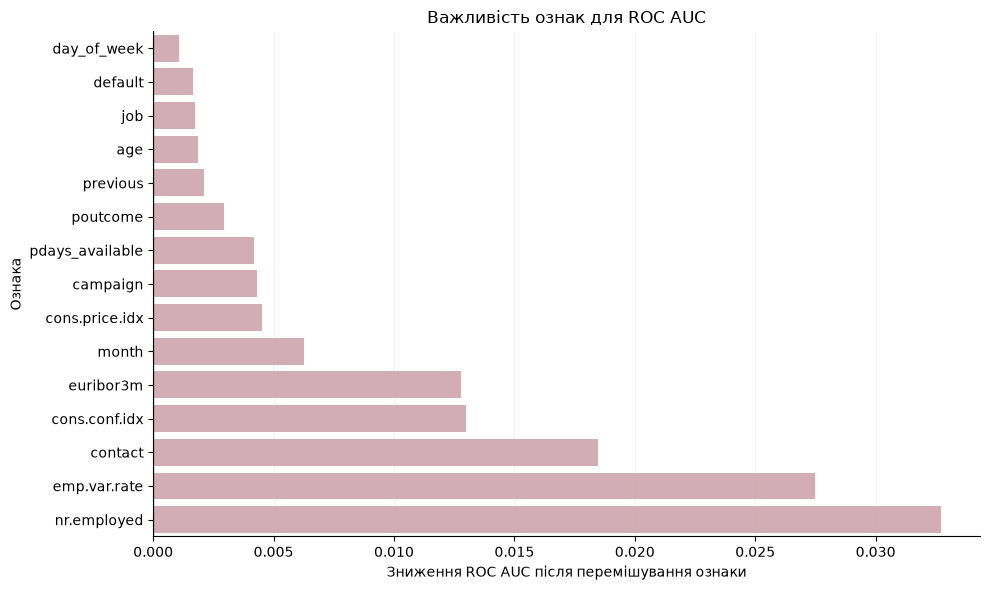

<Axes: title={'center': 'Важливість ознак для ROC AUC'}, xlabel='Зниження ROC AUC після перемішування ознаки', ylabel='Ознака'>

In [78]:
plot_feature_importance(lightgbm_feature_importance, top_n=15)

### Висновок щодо важливості

Найважливішими стали `nr.employed`, `emp.var.rate`, `contact`, `cons.conf.idx` і `euribor3m`. Це логічно: рішення клієнта залежить від економічної ситуації та способу контакту. Частина важливості розподіляється між корельованими економічними показниками.

## SHAP-аналіз

In [79]:
X_shap = X_val.sample(n=1_000, random_state=RANDOM_STATE)
lightgbm_preprocessor = selected_lightgbm_model.named_steps["preprocessor"]
lightgbm_classifier = selected_lightgbm_model.named_steps["classifier"]

X_shap_transformed = lightgbm_preprocessor.transform(X_shap)
transformed_feature_names = lightgbm_preprocessor.get_feature_names_out()

shap_explainer = shap.TreeExplainer(lightgbm_classifier)
shap_values = shap_explainer(X_shap_transformed)
shap_values.feature_names = list(transformed_feature_names)

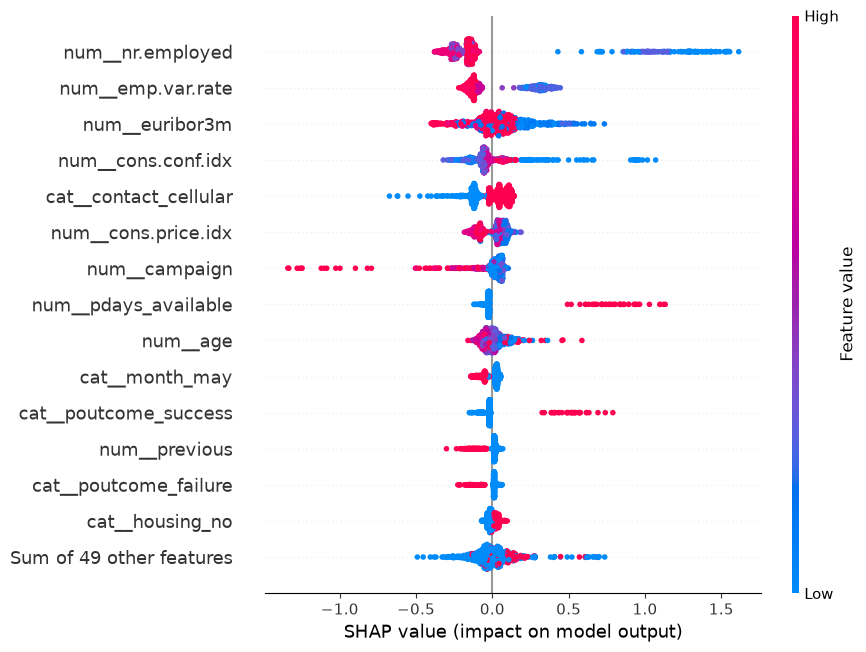

In [80]:
shap.plots.beeswarm(shap_values, max_display=15)

In [81]:
shap_importance = pd.DataFrame(
    {
        "feature": transformed_feature_names,
        "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
    }
).sort_values("mean_abs_shap", ascending=False)

shap_importance.head(15)

,feature,mean_abs_shap
8,num__nr.employed,0.308432
4,num__emp.var.rate,0.188786
7,num__euribor3m,0.124147
6,num__cons.conf.idx,0.096724
43,cat__contact_cellular,0.093375
5,num__cons.price.idx,0.073848
1,num__campaign,0.064281
9,num__pdays_available,0.060007
0,num__age,0.051747
51,cat__month_may,0.042883


### Висновок із SHAP

SHAP показав, що нижчі `nr.employed` та `euribor3m`, мобільний контакт, доступна історія `pdays` і успішна попередня кампанія підвищують прогноз `yes`. Велика кількість контактів `campaign` і місяць `may` частіше знижують його. Ці напрямки загалом узгоджуються з EDA.

## Фінальна оцінка на test

In [82]:
X_train_final = pd.concat([X_train, X_val], ignore_index=True)
y_train_final = pd.concat([y_train, y_val], ignore_index=True)

final_lightgbm_model = build_lightgbm_pipeline(
    num_cols,
    cat_cols,
    **selected_lightgbm_parameters,
)
final_lightgbm_model.fit(X_train_final, y_train_final)

final_test_evaluation = evaluate_model(
    final_lightgbm_model,
    X_train_final,
    y_train_final,
    X_test,
    y_test,
    model_name="Фінальна LightGBM",
    eval_name="Test",
)

final_test_evaluation

Фінальна LightGBM — Test classification report:
              precision    recall  f1-score   support

           0     0.9520    0.8788    0.9139      7308
           1     0.4054    0.6509    0.4996       928

    accuracy                         0.8531      8236
   macro avg     0.6787    0.7648    0.7067      8236
weighted avg     0.8904    0.8531    0.8672      8236



,ROC AUC,PR AUC,Recall,Precision,F1,Accuracy
Фінальна LightGBM,,,,,,
Train,0.8344,0.5175,0.6443,0.3963,0.4908,0.8494
Test,0.8170,0.4939,0.6509,0.4054,0.4996,0.8531


## Аналіз помилок

In [83]:
test_predictions = final_lightgbm_model.predict(X_test)
positive_class_index = list(final_lightgbm_model.classes_).index(1)
test_probabilities = final_lightgbm_model.predict_proba(X_test)[:, positive_class_index]

test_error_analysis = X_test.copy()
test_error_analysis["actual"] = y_test.to_numpy()
test_error_analysis["prediction"] = test_predictions
test_error_analysis["probability_yes"] = test_probabilities
test_error_analysis["error_type"] = np.select(
    [
        test_error_analysis["actual"].eq(0) & test_error_analysis["prediction"].eq(1),
        test_error_analysis["actual"].eq(1) & test_error_analysis["prediction"].eq(0),
    ],
    ["False Positive", "False Negative"],
    default="Correct",
)

test_error_analysis["error_type"].value_counts().to_frame("count")

,count
error_type,
Correct,7026
False Positive,886
False Negative,324


In [84]:
error_profiles = (
    test_error_analysis.query("error_type != 'Correct'")
    .groupby("error_type")[["age", "campaign", "previous", "pdays_available"]]
    .mean()
    .round(2)
)
error_profiles

,age,campaign,previous,pdays_available
error_type,,,,
False Negative,39.05,2.65,0.09,0.00
False Positive,40.35,1.95,0.45,0.13


In [85]:
high_confidence_errors = test_error_analysis.query("error_type != 'Correct'").assign(
    confidence=lambda data: np.where(
        data["prediction"].eq(1),
        data["probability_yes"],
        1 - data["probability_yes"],
    )
)

high_confidence_errors.sort_values("confidence", ascending=False)[
    [
        "error_type",
        "actual",
        "prediction",
        "probability_yes",
        "age",
        "job",
        "campaign",
        "previous",
        "poutcome",
    ]
].head(10)

,error_type,actual,prediction,probability_yes,age,job,campaign,previous,poutcome
39598,False Positive,0,1,0.956462,18,student,1,2,success
40148,False Positive,0,1,0.955488,32,admin.,2,1,success
40154,False Positive,0,1,0.950511,32,admin.,2,1,success
40946,False Positive,0,1,0.949670,63,admin.,2,1,success
39082,False Positive,0,1,0.949301,35,blue-collar,1,3,success
40701,False Positive,0,1,0.948784,30,technician,1,1,success
39117,False Positive,0,1,0.948390,59,management,3,1,success
40161,False Positive,0,1,0.947912,26,technician,2,1,success
39296,False Positive,0,1,0.947402,28,admin.,1,1,success
39341,False Positive,0,1,0.947171,33,services,2,1,success


### Фінальний висновок

Після навчання на train+validation фінальна LightGBM отримала на test ROC AUC 0.8170, PR AUC 0.4939 і recall 0.6509. Модель зробила 886 false positive та 324 false negative. Найвпевненіші false positive часто мали успішну попередню кампанію, тому модель інколи переоцінює цей сигнал. Далі я б підбирала поріг за вартістю дзвінка, калібрувала ймовірності та окремо перевірила клієнтів без попередніх контактів.